In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [3]:
txn=pd.read_csv("C:\\Users\\ABHILASH\\mutual_fund_project\\data\\raw\\08_investor_transactions.csv")

In [6]:
txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [11]:
print(txn.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


In [12]:
print(txn.head())

  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female                54.4   
4        Delhi      Noida       T30     26-35    Male                14.5   

  payment_mode kyc_status  
0          UPI   Verified  
1       Cheque   Verified  
2      M

In [14]:
print(txn.shape)

(32778, 13)


In [15]:
print(txn.isnull())

       investor_id  transaction_date  amfi_code  transaction_type  amount_inr  \
0            False             False      False             False       False   
1            False             False      False             False       False   
2            False             False      False             False       False   
3            False             False      False             False       False   
4            False             False      False             False       False   
...            ...               ...        ...               ...         ...   
32773        False             False      False             False       False   
32774        False             False      False             False       False   
32775        False             False      False             False       False   
32776        False             False      False             False       False   
32777        False             False      False             False       False   

       state   city  city_t

In [16]:
txn.fillna(0, inplace=True)

In [17]:
txn['transaction_date'] = pd.to_datetime(
    txn['transaction_date']
)

In [18]:
txn.dtypes

investor_id                   object
transaction_date      datetime64[ns]
amfi_code                      int64
transaction_type              object
amount_inr                     int64
state                         object
city                          object
city_tier                     object
age_group                     object
gender                        object
annual_income_lakh           float64
payment_mode                  object
kyc_status                    object
dtype: object

In [19]:
age_count = txn['age_group'].value_counts()

print(age_count)

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64


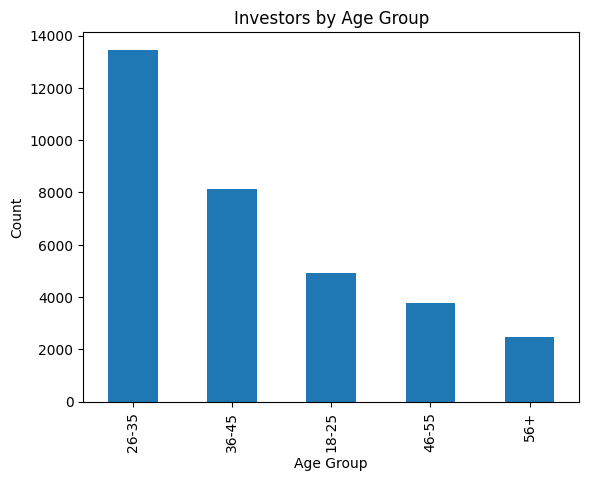

In [20]:
age_count.plot(kind='bar')

plt.title("Investors by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

In [21]:
gender_count = txn['gender'].value_counts()

print(gender_count)

gender
Male      21809
Female    10969
Name: count, dtype: int64


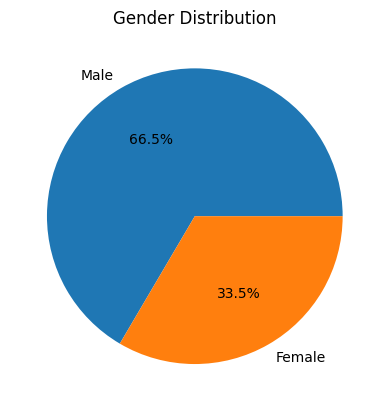

In [22]:
gender_count.plot(kind='pie', autopct='%1.1f%%')

plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

In [23]:
income_analysis = txn.groupby(
    'annual_income_lakh'
)['amount_inr'].mean()

print(income_analysis.head())

annual_income_lakh
3.0    105786.448276
3.1    108559.198473
3.2    117743.542857
3.3    110498.591837
3.4    135781.581395
Name: amount_inr, dtype: float64


In [24]:
txn_type = txn.groupby(
    'transaction_type'
)['amount_inr'].sum()

print(txn_type)

transaction_type
Lumpsum       2059821448
Redemption    1244525491
SIP            217233491
Name: amount_inr, dtype: int64


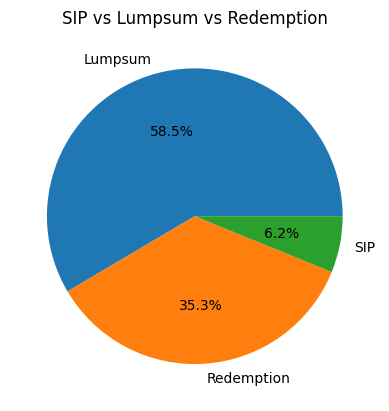

In [25]:
txn_type.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("SIP vs Lumpsum vs Redemption")
plt.ylabel("")
plt.show()

In [26]:
state_txn = txn.groupby(
    'state'
)['amount_inr'].sum()

state_txn = state_txn.sort_values(
    ascending=False
)

print(state_txn.head(10))

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Name: amount_inr, dtype: int64


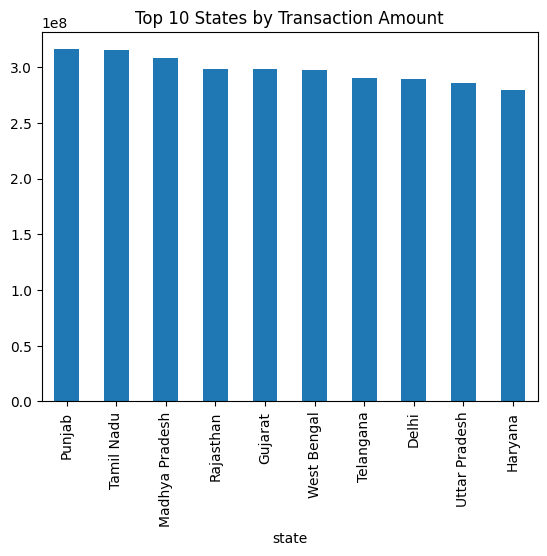

In [27]:
state_txn.head(10).plot(
    kind='bar'
)

plt.title("Top 10 States by Transaction Amount")
plt.show()

In [28]:
tier_txn = txn.groupby(
    'city_tier'
)['amount_inr'].sum()

print(tier_txn)

city_tier
B30    1202325640
T30    2319254790
Name: amount_inr, dtype: int64


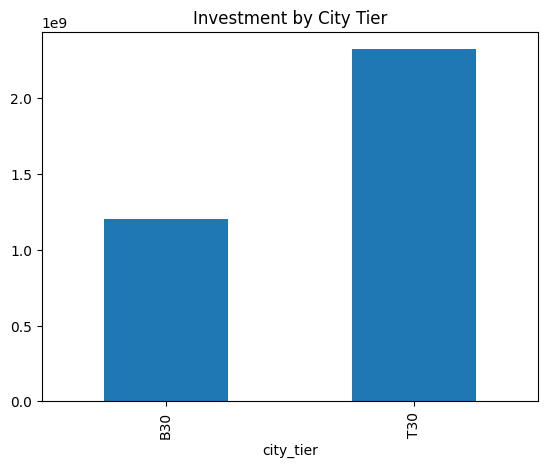

In [29]:
tier_txn.plot(kind='bar')

plt.title("Investment by City Tier")
plt.show()

In [30]:
txn['month'] = txn['transaction_date'].dt.to_period('M')

In [31]:
txn['month'] = txn['transaction_date'].dt.to_period('M')

In [33]:
monthly_txn = txn.groupby(
    'month'
)['amount_inr'].sum()

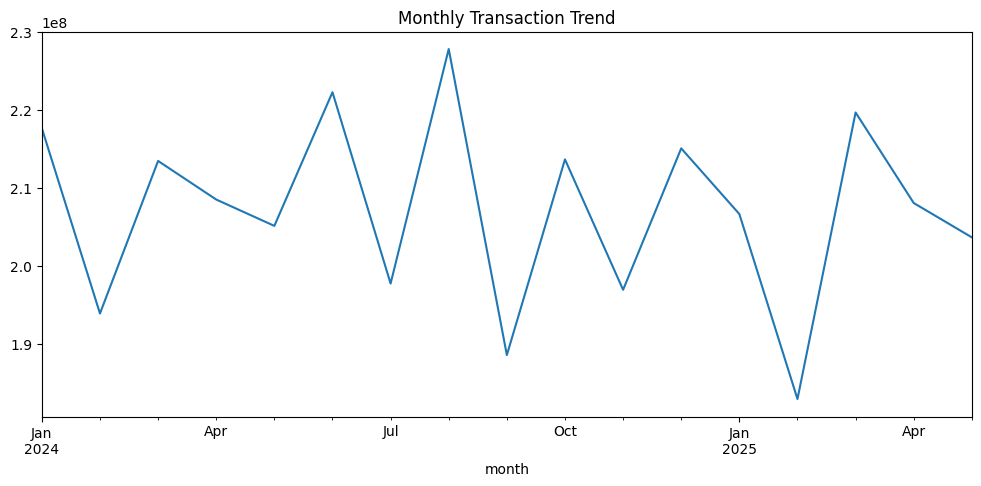

In [34]:
monthly_txn.plot(figsize=(12,5))

plt.title("Monthly Transaction Trend")
plt.show()

In [35]:
age_investment = txn.groupby(
    'age_group'
)['amount_inr'].mean()

print(age_investment)

age_group
18-25    108144.709520
26-35    107821.452722
36-45    107003.133808
46-55    107278.769251
56+      105613.105497
Name: amount_inr, dtype: float64


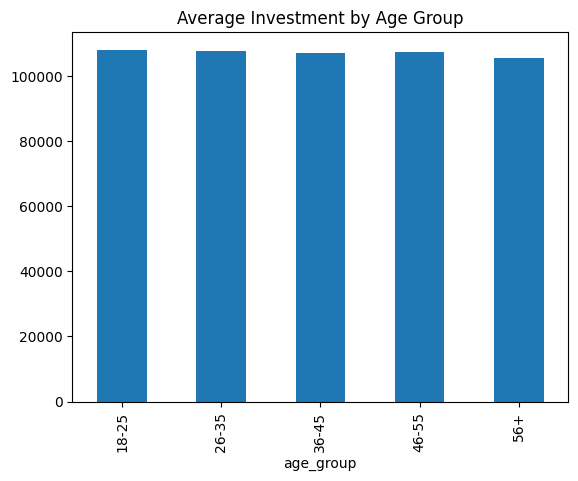

In [36]:
age_investment.plot(
    kind='bar'
)

plt.title("Average Investment by Age Group")
plt.show()

In [37]:
kyc = txn['kyc_status'].value_counts()

print(kyc)

kyc_status
Verified    30146
Pending      2632
Name: count, dtype: int64


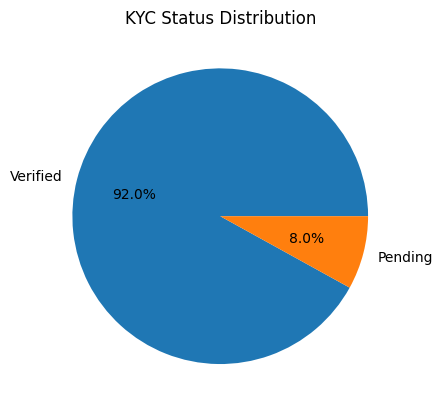

In [38]:
kyc.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("KYC Status Distribution")
plt.ylabel("")
plt.show()

In [39]:
state_txn.to_csv(
    "statewise_transactions.csv"
)

In [40]:
monthly_txn.to_csv(
    "monthly_trends.csv"
)

In [41]:
age_investment.to_csv(
    "agegroup_analysis.csv"
)

In [42]:
txn['transaction_type'].value_counts()

transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

In [43]:
state_txn = txn.groupby('state')['amount_inr'].sum()

state_txn.sort_values(
    ascending=False
).head(10)

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Name: amount_inr, dtype: int64

In [44]:
age_investment = txn.groupby(
    'age_group'
)['amount_inr'].sum()

print(age_investment.sort_values(
    ascending=False
))

age_group
26-35    1451600218
36-45     871647528
18-25     531639392
46-55     405406469
56+       261286823
Name: amount_inr, dtype: int64


In [45]:
tier_txn = txn.groupby(
    'city_tier'
)['amount_inr'].sum()

print(tier_txn.sort_values(
    ascending=False
))

city_tier
T30    2319254790
B30    1202325640
Name: amount_inr, dtype: int64


In [47]:
txn['gender'].value_counts()


gender
Male      21809
Female    10969
Name: count, dtype: int64

In [48]:
txn['kyc_status'].value_counts()

kyc_status
Verified    30146
Pending      2632
Name: count, dtype: int64

In [50]:

summary = {
    'Metric': [
        'Total Transactions',
        'SIP Transactions',
        'Lumpsum Transactions',
        'Redemption Transactions',
        'Top Age Group',
        'Top State',
        'Dominant Gender',
        'Verified KYC %'
    ],
    'Value': [
        len(txn),
        19716,
        8095,
        4967,
        '26-35',
        'Punjab',
        'Male',
        '92%'
    ]
}

import pandas as pd

demo_summary = pd.DataFrame(summary)

demo_summary.to_csv(
    'demographic_summary.csv',
    index=False
)

print(demo_summary)



                    Metric   Value
0       Total Transactions   32778
1         SIP Transactions   19716
2     Lumpsum Transactions    8095
3  Redemption Transactions    4967
4            Top Age Group   26-35
5                Top State  Punjab
6          Dominant Gender    Male
7           Verified KYC %     92%


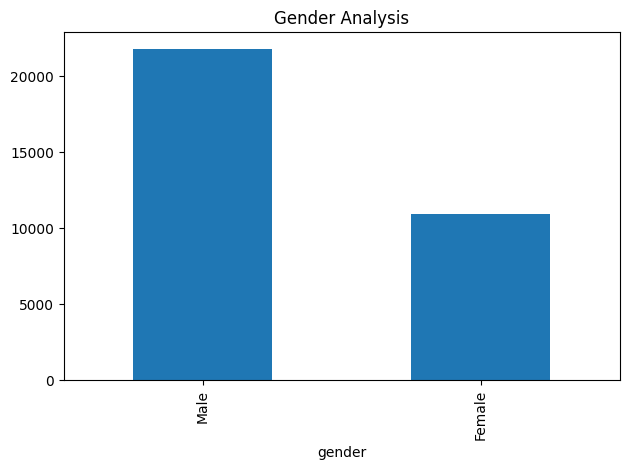

In [51]:
import matplotlib.pyplot as plt

gender_counts = txn['gender'].value_counts()

gender_counts.plot(kind='bar')
plt.title('Gender Analysis')
plt.tight_layout()
plt.savefig('C:\\Users\\ABHILASH\\mutual_fund_project\\reports\\charts\\gender_analysis.png')
plt.show()

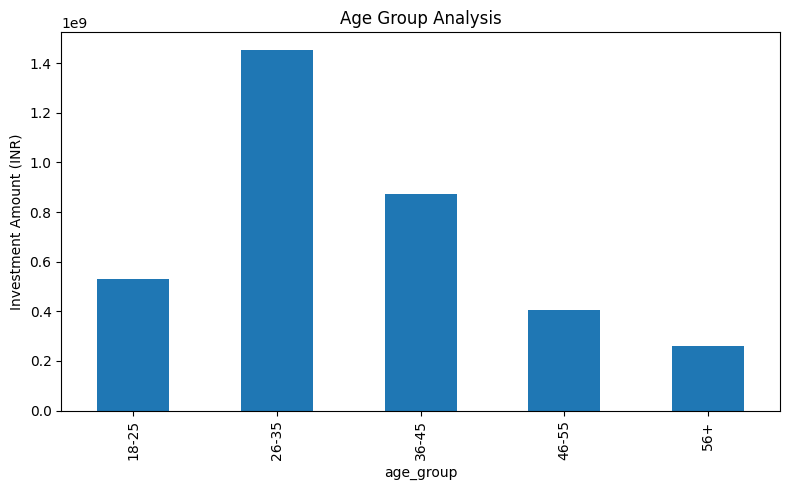

In [53]:
import matplotlib.pyplot as plt

age_data = txn.groupby('age_group')['amount_inr'].sum()

plt.figure(figsize=(8,5))
age_data.plot(kind='bar')
plt.title('Age Group Analysis')
plt.ylabel('Investment Amount (INR)')
plt.tight_layout()
plt.savefig('C:\\Users\\ABHILASH\\mutual_fund_project\\reports\\charts\\age_group_analysis.png')
plt.show()

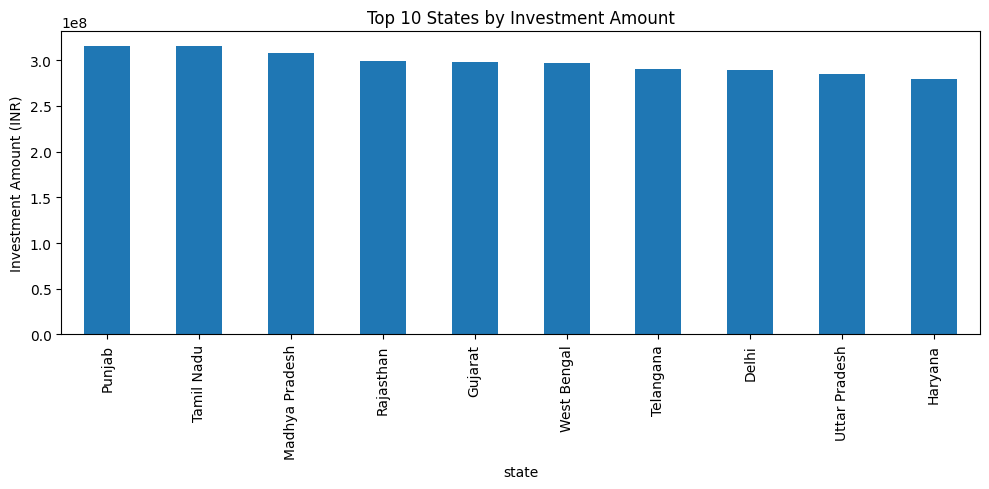

In [54]:
import matplotlib.pyplot as plt

state_data = txn.groupby('state')['amount_inr'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
state_data.plot(kind='bar')
plt.title('Top 10 States by Investment Amount')
plt.ylabel('Investment Amount (INR)')
plt.tight_layout()
plt.savefig('C:\\Users\\ABHILASH\\mutual_fund_project\\reports\\charts\\state_analysis.png')
plt.show()

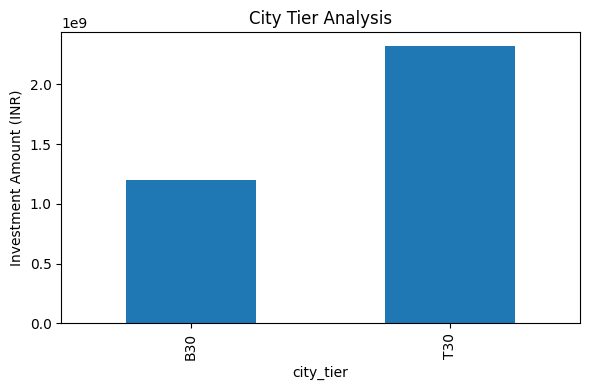

In [55]:
import matplotlib.pyplot as plt

tier_data = txn.groupby('city_tier')['amount_inr'].sum()

plt.figure(figsize=(6,4))
tier_data.plot(kind='bar')
plt.title('City Tier Analysis')
plt.ylabel('Investment Amount (INR)')
plt.tight_layout()
plt.savefig('C:\\Users\\ABHILASH\\mutual_fund_project\\reports\\charts\\city_tier_analysis.png')
plt.show()

In [58]:
import os

print(os.listdir('C:\\Users\\ABHILASH\\mutual_fund_project\\reports\\charts'))

['age_distribution.png', 'age_group_analysis.png', 'age_group_distribution.png', 'amount_boxplot_age_group.png', 'aum_growth.png', 'category_heatmap.png', 'city_tier_analysis.png', 'city_tier_split.png', 'correlation_matrix.png', 'folio_growth.png', 'fund_category_distribution.png', 'gender_analysis.png', 'gender_distribution.png', 'gender_split.png', 'nav_correlation_matrix.png', 'nav_trend.png', 'payment_mode_distribution.png', 'sector_allocation.png', 'sip_inflow.png', 'slip_boxplot.png', 'state_analysis.png', 'state_distribution.png', 'state_investment_distribution.png', 't30_b30_distribution.png', 'transaction_type_distribution.png']


In [59]:
txn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   investor_id         32778 non-null  object        
 1   transaction_date    32778 non-null  datetime64[ns]
 2   amfi_code           32778 non-null  int64         
 3   transaction_type    32778 non-null  object        
 4   amount_inr          32778 non-null  int64         
 5   state               32778 non-null  object        
 6   city                32778 non-null  object        
 7   city_tier           32778 non-null  object        
 8   age_group           32778 non-null  object        
 9   gender              32778 non-null  object        
 10  annual_income_lakh  32778 non-null  float64       
 11  payment_mode        32778 non-null  object        
 12  kyc_status          32778 non-null  object        
 13  month               32778 non-null  period[M] 

In [60]:
txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,month
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024-01
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024-01
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024-01
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024-01
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024-01


In [2]:
import os

print(os.getcwd())
print("\nFiles and folders:\n")

for item in os.listdir():
    print(item)

c:\Users\ABHILASH\mutual_fund_project\notebooks

Files and folders:

agegroup_analysis.csv
demographic_summary.csv
EDA_Analysis.ipynb
Investor_Analytics.ipynb
monthly_trends.csv
Performance_Analytics.ipynb
SQL_Validation.ipynb
statewise_transactions.csv


In [3]:
for name in globals():
    if not name.startswith("_"):
        print(name)

RuntimeError: dictionary changed size during iteration

In [4]:
for name in list(globals().keys()):
    if not name.startswith("_"):
        print(name)

In
Out
get_ipython
exit
quit
open
os
item
name


In [5]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

.\agegroup_analysis.csv
.\demographic_summary.csv
.\monthly_trends.csv
.\statewise_transactions.csv


In [6]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

.\agegroup_analysis.csv
.\demographic_summary.csv
.\monthly_trends.csv
.\statewise_transactions.csv
